<a href="https://colab.research.google.com/github/SathyaPrakashD/ml-pipeline-fundamentals/blob/main/11_diabetes_progression_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Disease Progression — Regression

## Objective
Predict the measure of diabetes disease progression one year after
baseline using physiological and blood serum measurements.

## Dataset
- Source: sklearn.datasets.load_diabetes
- 442 patients, 10 features
- Target: Continuous disease progression score (higher = worse progression)
- No missing values — clean dataset

## EDA Findings
- Target skew: 0.44 — mild right skew
- Strongest feature correlations with target: bmi (0.59), s5 (0.57), bp (0.44)
- Multicollinearity identified: s1↔s2 (0.90), s3↔s4 (-0.74)
- All features numeric — no ColumnTransformer needed

## Approach
- Full EDA: Target distribution, skew, feature correlation heatmap
- Lead metric: RMSE — large errors clinically dangerous in medical context
- Model: Linear Regression — moderate linear correlations confirmed by heatmap
- Feature Engineering: bmi_age (bmi × age), bp_bmi (bp × bmi)
- Multicollinearity removal: Dropped s2, s4
- Regularisation: Ridge (alpha=1.0) tested

## Optimisation Journey
| Step | R² |
|------|-----|
| Baseline Linear Regression | 0.4526 |
| + Feature Engineering | 0.4799 |
| + Drop multicollinear features | 0.4881 |
| + Ridge Regression | 0.4883 |

## Results (Final Model)
| Metric | Score |
|--------|-------|
| MAE | 42 |
| RMSE | 52 |
| R² | 0.4883 |

## Key Learnings
- R² measures explanatory power — 49% of progression variance explained
- Remaining 51% driven by factors not in dataset (diet, genetics, lifestyle)
- Feature engineering improved R² more than model switching
- Multicollinearity removal stabilised Linear Regression coefficients
- Ridge added marginal gain — manual feature removal already handled most damage
- Lead metric is always decided by use case — RMSE for clinical, MAE for equal-cost errors

## 1. Load & Inspect Data

Load the diabetes dataset from `sklearn.datasets`, wrap it into a Pandas DataFrame, attach the target column, and perform an initial inspection of shape, feature names, and value distributions.

In [19]:
# ============================================================
# CHECKPOINT 1 — Load & Inspect Data
# ============================================================

from sklearn.datasets import load_diabetes

# Step 1 — Load the dataset
import pandas as pd
import numpy as np





# Load the diabetes dataset from sklearn
data = load_diabetes()

# Print the feature names to understand the dataset columns
print(data.feature_names)

# Step 2 — Wrap features into a DataFrame
# The 'data.data' attribute contains the feature values, and 'data.feature_names' provides column headers.
df = pd.DataFrame(data.data, columns=data.feature_names)


# Step 3 — Add the target column
# The 'data.target' attribute contains the disease progression scores.
df['target'] = data.target

# Display the first 5 rows of the DataFrame to quickly inspect the data
df.head(5)


# Print the shape of the DataFrame (number of rows, number of columns)
print("Shape:", df.shape)
# Print the value counts of the target variable (disease progression score)
# This helps understand the distribution of the target values.
print("Classes:", df['target'].value_counts())
print("\nFirst 5 rows:")
print(df.head())

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Shape: (442, 11)
Classes: target
200.0    6
72.0     6
178.0    5
71.0     5
90.0     5
        ..
146.0    1
212.0    1
120.0    1
183.0    1
57.0     1
Name: count, Length: 214, dtype: int64

First 5 rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [20]:
# Check for missing values across all columns in the DataFrame
# .isnull() creates a boolean DataFrame indicating missing values
# .sum() counts the number of True values (missing) per column
# .sort_values(ascending=False) orders columns by missing count from highest to lowest
# .head(20) displays the top 20 columns with missing values (if any)
print(df.isnull().sum().sort_values(ascending=False).head(20))

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


**No missing values — no imputation needed. Clean dataset.**


## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Distribution

Plot the distribution of the target variable (disease progression score) with a histogram and KDE overlay. Examine its shape and compute skewness to inform imputation strategy and lead metric selection.

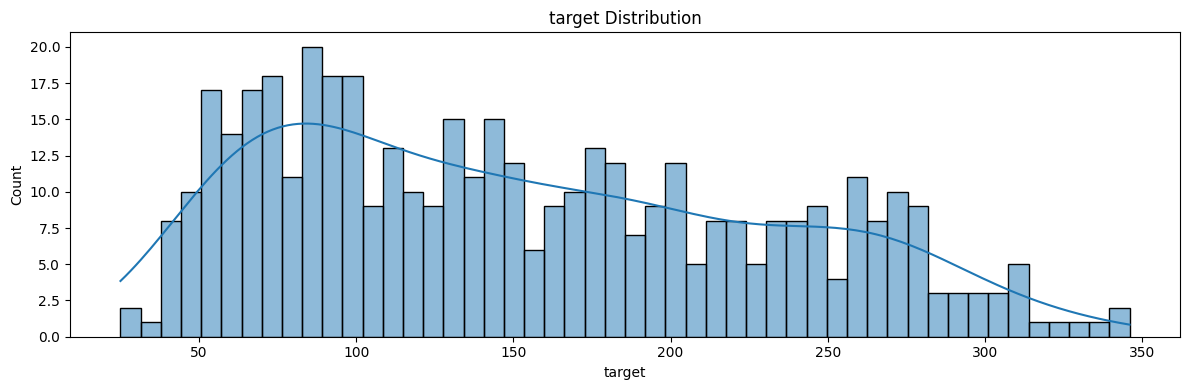

target skew: 0.4406


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots with a specified size
fig, axes = plt.subplots(1, 1, figsize=(12, 4))


# Plot the distribution of the 'target' variable using a histogram with KDE (Kernel Density Estimate)
# bins=50 specifies the number of bins for the histogram
# kde=True overlays a smooth curve representing the probability density function
# ax=axes specifies that the plot should be drawn on the created axes
sns.histplot(df['target'], bins=50, kde=True, ax=axes)
# Set the title for the plot
axes.set_title('target Distribution')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Display the plot
plt.show()

# Calculate and print the skewness of the 'target' distribution
# Skewness indicates the asymmetry of the probability distribution
# A positive value means a right (positive) skew, a negative value means a left (negative) skew
print(f"target skew: {df['target'].skew():.4f}")

In [22]:
df.shape # Output the number of rows and columns in the DataFrame.

(442, 11)

Two questions before you move to the heatmap:

Given skew = 0.44 — which imputation strategy would you use if there were missing values? Mean or median?
Given this is a medical prediction with a right skewed target — which lead metric do you lean toward, MAE or RMSE? Think about the cost of large errors in a clinical setting before answering.

A small error (predicting 90 when actual is 100) → doctor makes a slightly adjusted treatment plan. Manageable.
A large error (predicting 80 when actual is 280) → doctor significantly underestimates disease severity → patient gets inadequate treatment → serious health consequences.

In clinical settings, large errors are not just inconvenient — they're dangerous.
Which metric punishes large errors heavily?

**RMSE**

### 2.2 Feature Type Analysis

Check dataset dimensions and count numeric vs. categorical columns to determine whether a `ColumnTransformer` is needed or if a simple `StandardScaler` suffices.

In [23]:
print(f"Shape after cleaning: {df.shape}")
# Count the number of numeric columns (int64, float64)
print(f"\nNumeric columns    : {df.select_dtypes(include=['int64','float64']).shape[1]}")
# Count the number of categorical columns (object type)
print(f"Categorical columns: {df.select_dtypes(include=['object']).shape[1]}")

Shape after cleaning: (442, 11)

Numeric columns    : 11
Categorical columns: 0


**all numeric, no categorical columns. ColumnTransformer is unnecessary here. A simple StandardScaler in the pipeline is sufficient.**

### 2.3 Feature Correlation Heatmap

Compute pairwise correlations between all features and the target. The heatmap reveals which features have the strongest linear relationship with disease progression and highlights multicollinearity between predictors.

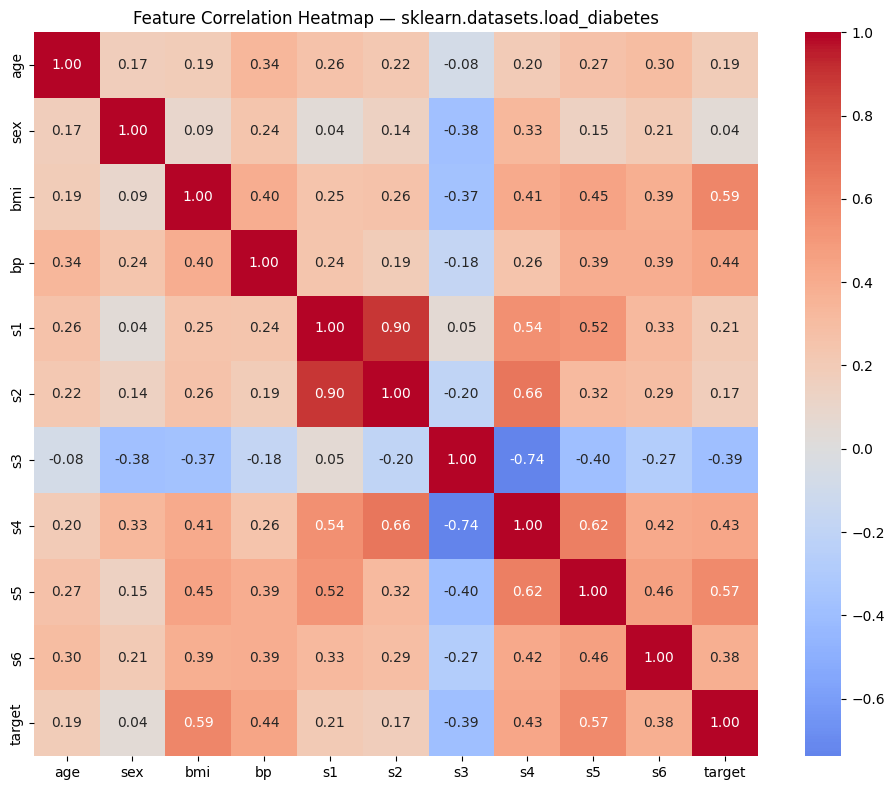

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better visualization of the heatmap
plt.figure(figsize=(10, 8))
# Create a correlation heatmap using seaborn
# df.corr() calculates the pairwise correlation of columns
# annot=True displays the correlation values on the heatmap
# fmt='.2f' formats the annotation values to two decimal places
# cmap='coolwarm' sets the color map to 'coolwarm'
# center=0 sets the color scale to be centered at 0, highlighting positive and negative correlations
# square=True ensures the cells are square for better readability
sns.heatmap(df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
# Set the title of the heatmap
plt.title('Feature Correlation Heatmap — sklearn.datasets.load_diabetes')
# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Display the plot
plt.show()

## Key Correlation Observations

| Feature | Correlation with Target | Observation |
|---|---|---|
| `bmi` | 0.59 | Strongest positive correlation, suggesting a significant linear relationship with disease progression. |
| `s5` | 0.57 | Second strongest positive correlation, also indicating a strong linear relationship. |
| `bp` | 0.44 | Third strongest positive correlation. |

### Multicollinearity:
*   `s1` and `s2` have a strong positive multicollinearity (0.90).
*   `s3` and `s4` have a strong negative multicollinearity (-0.74).

### Model Selection Reasoning:
The correlations with the target are moderate and spread across multiple features, without a single dominant non-linear feature. This suggests that the relationships are reasonably linear, with multiple features contributing moderate linear signals. Therefore, **Linear Regression is a reasonable starting point**, and **Random Forest can serve as a strong comparison model**.

## 3. Data Splitting & Scaling

Split the dataset into training (80%) and test (20%) sets **before** applying `StandardScaler`. Fitting the scaler only on training data prevents data leakage and ensures the test set truly represents unseen data.

In [25]:
# ============================================================
# CHECKPOINT 2 — Split first, then Scale (correct order)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1 — Separate features and target
# X will contain all feature columns, y will contain the target variable.
X = df.drop(columns=['target'])
y = df['target']

# Step 2 — Split data into training and testing sets BEFORE scaling
# test_size=0.2 means 20% of the data will be used for testing, and 80% for training.
# random_state fixes the random split so that results are reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print the sizes of the training and testing sets to verify the split.
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Step 3 — Initialize StandardScaler and fit it only on the TRAIN data
# This prevents data leakage from the test set into the training process.
scaler = StandardScaler()
scaler.fit(X_train)             # learns mean & std from train only

# Step 4 — Transform both training and testing sets using the statistics learned from the training set
# This ensures consistency in scaling across both datasets.
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# Step 5 — Verify scaling worked by comparing the head of DataFrames before and after scaling
# Convert scaled arrays back to DataFrames for easy inspection with column names.
X_train_df_before = pd.DataFrame(X_train, columns=X.columns)
print("\nBefore scaling (train set):")
print(X_train_df_before.head())

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\nAFTER scaling (train set):")
print(X_train_df.head())

Train size: 353
Test size: 89

Before scaling (train set):
          age       sex       bmi        bp        s1        s2        s3  \
17   0.070769  0.050680  0.012117  0.056301  0.034206  0.049416 -0.039719   
66  -0.009147  0.050680 -0.018062 -0.033213 -0.020832  0.012152 -0.072854   
137  0.005383 -0.044642  0.049840  0.097615 -0.015328 -0.016345 -0.006584   
245 -0.027310 -0.044642 -0.035307 -0.029770 -0.056607 -0.058620  0.030232   
31  -0.023677 -0.044642 -0.065486 -0.081413 -0.038720 -0.053610  0.059685   

           s4        s5        s6  
17   0.034309  0.027364 -0.001078  
66   0.071210  0.000272  0.019633  
137 -0.002592  0.017036 -0.013504  
245 -0.039493 -0.049872 -0.129483  
31  -0.076395 -0.037129 -0.042499  

AFTER scaling (train set):
        age       sex       bmi        bp        s1        s2        s3  \
0  1.498365  1.061370  0.219902  1.138874  0.728473  1.055893 -0.824451   
1 -0.228858  1.061370 -0.419366 -0.710591 -0.424929  0.272425 -1.529791   
2  0.0851

## 4. Model Training — Linear Regression

Build a `Pipeline` with `StandardScaler` and `LinearRegression`. Train on 80% of the data, predict on the test set, and evaluate with MAE, RMSE, and R² — chosen as lead metrics based on EDA insights.

In [26]:
# ============================================================
# CHECKPOINT 3 — Train Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression # Import LinearRegression model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Import regression metrics
import numpy as np # Import numpy for numerical operations

# Create a pipeline that first scales the data and then applies Linear Regression
# This ensures that scaling is consistently applied during both training and prediction
pipeline = Pipeline([
    ('scaler', StandardScaler()), # Step 1: Scale features using StandardScaler
    ('model', LinearRegression()) # Step 2: Apply Linear Regression model
])

# Train the pipeline on the scaled training data
# The scaler learns parameters from X_train and transforms it, then the Linear Regression model is fitted.
pipeline.fit(X_train, y_train)

# Predict on the test set using the trained pipeline
# The X_test data is first scaled internally by the pipeline's scaler, then predictions are made.
y_pred = pipeline.predict(X_test)

# Calculate various regression metrics to evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # RMSE is the square root of MSE
mae = mean_absolute_error(y_test, y_pred)

# Print the calculated metrics
print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"rmse : {rmse:.4f}")


# Inspect one prediction to see a comparison between true and predicted values
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])

MAE: 42.7941
Mean Squared Error: 2900.1936
R-squared: 0.4526
rmse : 53.8534

First test sample — true label   : 219.0
First test sample — predicted    : 139.54755840379613


## 5. Model Training — Random Forest

Train a `RandomForestRegressor` with 100 estimators in a pipeline with `StandardScaler`. Compare its performance against Linear Regression to determine which model better captures the feature-target relationships in this dataset.

In [27]:
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor model
from sklearn.model_selection import cross_val_score # Import cross_val_score for potential future use (not directly used here for final model evaluation)
from sklearn.pipeline import Pipeline # Import Pipeline for creating an estimator pipeline

# Create a pipeline that first scales the data and then applies Random Forest Regression
# This ensures that scaling is consistently applied during both training and prediction
pipeline = Pipeline([
    ('scaler', StandardScaler()), # Step 1: Scale features using StandardScaler
    ('model', RandomForestRegressor(n_estimators=100, random_state=42)) # Step 2: Apply RandomForestRegressor model
])

# Train the pipeline on the scaled training data
# The scaler learns parameters from X_train and transforms it, then the RandomForestRegressor model is fitted.
pipeline.fit(X_train, y_train)

# Step 2 — Predict on the test set using the trained pipeline
# The X_test data is first scaled internally by the pipeline's scaler, then predictions are made.
y_pred = pipeline.predict(X_test)


# Step 4 — Score it (using regression metrics)
# Calculate various regression metrics to evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # RMSE is the square root of MSE
mae = mean_absolute_error(y_test, y_pred)

# Print the calculated metrics
print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"rmse : {rmse:.4f}")


# Step 5 — Inspect one prediction
# Inspect one prediction to see a comparison between true and predicted values
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])

MAE: 44.1712
Mean Squared Error: 2959.1806
R-squared: 0.4415
rmse : 54.3984

First test sample — true label   : 219.0
First test sample — predicted    : 146.21


## 6. Model Comparison: Linear Regression vs. Random Forest

| Metric | Linear Regression | Random Forest | Better |
|---|---|---|---|
| MAE | 42.79 | 44.17 | Linear Regression |
| RMSE | 53.85 | 54.40 | Linear Regression |
| R² | 0.4526 | 0.4415 | Linear Regression |

### Conclusion
As observed from the metrics, **Linear Regression performs slightly better** than Random Forest for this dataset. This confirms what the correlation heatmap suggested earlier: the feature-target relationships are moderately linear, with multiple features contributing steady linear signals. In this scenario, the added complexity of Random Forest does not yield better performance and might even introduce noise on this relatively small dataset (442 rows).

## 7. Feature Engineering :

### New Features
Create new features from existing ones. For example:

bmi_age = bmi × age — older patients with high BMI may have disproportionately worse progression
bp_bmi = bp × bmi — combined cardiovascular risk signal

Domain knowledge drives this. A medical expert would know which combinations are clinically meaningful.



In [31]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X['bmi_age'] = X['bmi'] * X['age']
        X['bp_bmi'] = X['bp'] * X['bmi']
        return X

In [33]:
from sklearn.linear_model  import LinearRegression # Import RandomForestRegressor model
from sklearn.model_selection import cross_val_score # Import cross_val_score for potential future use (not directly used here for final model evaluation)
from sklearn.pipeline import Pipeline # Import Pipeline for creating an estimator pipeline

pipeline = Pipeline([
    ('feature_engineering', FeatureTransformer()),
    ('scaler', StandardScaler()), # Step 1: Scale features using StandardScaler
    ('model', LinearRegression()) # Step 2: Apply RandomForestRegressor model
])



# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")




# Step 5 — Inspect one prediction
# Inspect one prediction to see a comparison between true and predicted values
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])

MAE  : 42
RMSE : 52
R²   : 0.4799

First test sample — true label   : 219.0
First test sample — predicted    : 142.77735680425502


### 7.1  Feature Engineering Helped

| Metric | Baseline | With Feature Engineering | Change |
|---|---|---|---|
| MAE | 42.79 | 42 | ✅ Better |
| RMSE | 53.85 | 52 | ✅ Better |
| R² | 0.4526 | 0.4799 | ✅ Better |

R² jumped from 45.3% to 48% — the engineered features added real signal. `bmi_age` and `bp_bmi` captured interaction effects that the individual features couldn't express alone.

Still room to improve — R² of 48% means 52% of variance is still unexplained. But every improvement is evidence-based and justified.

### 7.2  Feature Engineering Helped


Option 2 was — remove multicollinear features (s1 and s2, s3 and s4).
Here's the question: does multicollinearity hurt Linear Regression enough to matter here?


---


Yes — it does. Linear Regression assigns weights to each feature independently. When s1 and s2 are 90% correlated, the model gets confused about how to split the weight between them — the coefficients become unstable.

Removing one from each pair could:

1. Stabilise the remaining coefficients
2. Reduce noise
3. Potentially improve R²


But there's a trade-off — you're removing features that carry real signal. s1 and s2 both correlate with the target (0.21 and 0.17). Dropping one means losing some information.


---


My honest prediction:

Combined with your existing feature engineering, dropping s2 and s4 might give a small improvement. But the gain is likely modest — the bigger R² gap comes from missing data (diet, genetics, lifestyle) that no feature engineering can fix.


R² jumped from 45.3% to 48% — the engineered features added real signal. `bmi_age` and `bp_bmi` captured interaction effects that the individual features couldn't express alone.


Still room to improve — R² of 48% means 52% of variance is still unexplained. But every improvement is evidence-based and justified.



---

My recommendation:


Try it — but treat it as a hypothesis to test, not a guaranteed win. Add it to your FeatureTransformer:


**X = X.drop(columns=['s2', 's4'])**


In [34]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X['bmi_age'] = X['bmi'] * X['age']
        X['bp_bmi'] = X['bp'] * X['bmi']
        X = X.drop(columns=['s2', 's4'])
        return X

In [35]:
from sklearn.linear_model  import LinearRegression # Import RandomForestRegressor model
from sklearn.model_selection import cross_val_score # Import cross_val_score for potential future use (not directly used here for final model evaluation)
from sklearn.pipeline import Pipeline # Import Pipeline for creating an estimator pipeline

pipeline = Pipeline([
    ('feature_engineering', FeatureTransformer()),
    ('scaler', StandardScaler()), # Step 1: Scale features using StandardScaler
    ('model', LinearRegression()) # Step 2: Apply RandomForestRegressor model
])



# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")




# Step 5 — Inspect one prediction
# Inspect one prediction to see a comparison between true and predicted values
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])

MAE  : 42
RMSE : 52
R²   : 0.4881

First test sample — true label   : 219.0
First test sample — predicted    : 145.89334787857706


**Small but real improvement**

| Metric | Baseline | + Feature Engineering | + Drop s2, s4 | Change |
|---|---|---|---|---|
| MAE | 42.79 | 42 | 42 | → Same |
| RMSE | 53.85 | 52 | 52 | → Same |
| R² | 0.4526 | 0.4799 | 0.4881 | ✅ Better |

R² nudged from 0.4799 → 0.4881. Removing multicollinear features stabilised the coefficients slightly — exactly as predicted.

### 7.3 Feature Engineering :

### Ridge Regresssion


Ridge and Lasso — what are they?

Both are regularised versions of Linear Regression. They do everything Linear Regression does — but add a penalty for large coefficients.

Why does that help with multicollinearity?
When s1 and s2 are 90% correlated, Linear Regression assigns unstable, sometimes very large weights to both. Ridge says:

"I'll keep both features — but I'll shrink their weights so neither dominates unfairly."

Lasso goes further:

"I'll shrink weak feature weights all the way to zero — effectively removing them."


---



Analogy:

Linear Regression is a team where everyone shouts at once — correlated features argue over credit.
Ridge is a manager who says "everyone contribute, but keep your voice down."
Lasso is a manager who says "only the most useful people speak — the rest sit down."


---


When to use which:

ModelBest whenLinear RegressionNo multicollinearity, clean featuresRidgeMulticollinearity exists — keep all featuresLassoMulticollinearity exists — want automatic feature selection



---


For your diabetes dataset:

You have s1↔s2 = 0.90 and s3↔s4 = -0.74. Ridge or Lasso would handle that more elegantly than manually dropping columns.



In [36]:
from sklearn.linear_model  import Ridge # Import  model
from sklearn.model_selection import cross_val_score # Import cross_val_score for potential future use (not directly used here for final model evaluation)
from sklearn.pipeline import Pipeline # Import Pipeline for creating an estimator pipeline

pipeline = Pipeline([
    ('feature_engineering', FeatureTransformer()),
    ('scaler', StandardScaler()), # Step 1: Scale features using StandardScaler
    ('model', Ridge(alpha=1.0)) # Step 2: Apply Ridge Regression model
])



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")


# Inspect one prediction to see a comparison between true and predicted values
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])

MAE  : 42
RMSE : 52
R²   : 0.4883

First test sample — true label   : 219.0
First test sample — predicted    : 146.00865780882617


### Marginal improvement

| Step | R² |
|---|---|
| Baseline Linear Regression | 0.4526 |
| + Feature Engineering | 0.4799 |
| + Drop s2, s4 | 0.4881 |
| + Ridge (alpha=1.0) | 0.4883 |

Ridge added almost nothing over dropping the multicollinear features manually — 0.4881 → 0.4883. That tells you:
Manually dropping s2 and s4 already handled most of the multicollinearity damage. Ridge had little left to fix.

The honest conclusion:
You've squeezed meaningful improvement out of this dataset through three evidence-based steps — from R² 0.45 to 0.49. The remaining 51% gap is largely a data problem, not a model problem. Without features like diet, exercise, genetics and medication — no amount of model tuning will close it.

Your optimisation journey — complete:

| Approach | Result |
|---|---|
| Tried feature engineering | ✅ Helped |
| Tried removing multicollinearity | ✅ Helped slightly |
| Tried Ridge regularisation | ✅ Marginal gain |
| Honest conclusion | Data completeness is the ceiling |

### Check Point -

custom patient profile → predicted disease progression score.

In [37]:

custom_patient = pd.DataFrame([{
    'age': 0.038076,
    'sex': 0.038076,
    'bmi': 0.038076,
    'bp': 0.038076,
    's1': 0.038076,
    's2': 0.038076,
    's3': 0.038076,
    's4': 0.038076,
    's5': 0.038076,
    's6': 0.038076
}])

predicted_score = pipeline.predict(custom_patient)[0]
print(f"Predicted disease progression score: {predicted_score:.1f}")

Predicted disease progression score: 183.8
